In [3]:
import numpy as np
from xrd_simulator.beam import Beam

# The beam of xrays is represented as a convex polyhedron
# We specify the vertices in a numpy array.
beam_vertices = np.array(
   [
      [-1e6, -500.0, -500.0],
      [-1e6, 500.0, -500.0],
      [-1e6, 500.0, 500.0],
      [-1e6, -500.0, 500.0],
      [1e6, -500.0, -500.0],
      [1e6, 500.0, -500.0],
      [1e6, 500.0, 500.0],
      [1e6, -500.0, 500.0],
   ]
)

beam = Beam(
   beam_vertices,
   xray_propagation_direction=np.array([1.0, 0.0, 0.0]),
   wavelength=0.28523,
   polarization_vector=np.array([0.0, 1.0, 0.0]),
)

In [4]:


from xrd_simulator.detector import Detector

# The detector plane is defined by it's corner coordinates det_corner_0,det_corner_1,det_corner_2
detector = Detector(
   det_corner_0=np.array([142938.3, -38400.0, -38400.0]),
   det_corner_1=np.array([142938.3, 38400.0, -38400.0]),
   det_corner_2=np.array([142938.3, -38400.0, 38400.0]),
   pixel_size=(55.0, 55.0),
   gaussian_sigma=1.0,
   max_gaussian_kernel_radius=5,
)



In [5]:
from xrd_simulator.mesh import TetraMesh

# xrd_simulator supports several ways to generate a mesh, here we
# generate meshed solid sphere using a level set.
mesh = TetraMesh.generate_mesh_from_levelset(
   level_set=lambda x: np.linalg.norm(x) - 210.0,
   bounding_radius=769.0,
   max_cell_circumradius=550.0,
)
print(mesh.number_of_elements)

1540


In [6]:


from xrd_simulator.phase import Phase

quartz = Phase(
   unit_cell=[4.926, 4.926, 5.4189, 90.0, 90.0, 120.0],
   sgname="P3221",  # (Quartz)
   path_to_cif_file="quartz.cif",  # phases can be defined from crystalographic information files
)

In [7]:


from scipy.spatial.transform import Rotation as R
from xrd_simulator.polycrystal import Polycrystal

orientation = R.random(mesh.number_of_elements).as_matrix()
# element_phase_map assigns each mesh element to a phase (0 = first phase)
element_phase_map = np.zeros(mesh.number_of_elements, dtype=int)
polycrystal = Polycrystal(
   mesh,
   orientation,
   strain=np.zeros((3, 3)),
   phases=quartz,
   element_phase_map=element_phase_map,
)

In [8]:
from xrd_simulator.motion import RigidBodyMotion

motion = RigidBodyMotion(
   rotation_axis=np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2)]),
   rotation_angle=np.radians(0.1),
   translation=np.array([123, -153.3, 3.42]),
)

In [9]:
from xrd_simulator.gaussian_crystal_model import GaussianGrainish, GaussianPolycrystal
import torch

def make_random_tensor(axis_1, axis_2):
    random_direction = np.random.normal(size=3)
    random_direction = random_direction/np.linalg.norm(random_direction)
    tensor = axis_1**2 * np.eye(3) + (axis_2**2-axis_1**2) * np.outer(random_direction, random_direction)
    return tensor

N = mesh.number_of_elements
grain_list = []

for ii in range(N):

    shape_tensor = torch.eye(3) * mesh.eradius[ii]**2

    misorientation_tensor = make_random_tensor(
        np.random.uniform(0.001, 0.001),
        np.random.uniform(0.001, 0.001),
    )

    grain = GaussianGrainish(
        phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
        position=mesh.espherecentroids[ii], # 3 vector centroid real-space position
        shape_tensor=shape_tensor, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
        orientation=orientation[ii], # 3-by-3 rotation matrix.
        misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
                                                     # misorientation vectors live in laboratory coordinates.
        strain_tensor=polycrystal.strain_lab[ii] # 3-by-3 symmetric strain tensor.
    )

    grain_list.append(grain)

gauss_polycrystal = GaussianPolycrystal(grain_list, max_misorientation=0.001, max_grain_size=50)


In [10]:
from xrd_simulator.beam import GaussianBeam

gaussian_beam = GaussianBeam(
    xray_propagation_direction=np.array([1.0, 0.0, 0.0]),
    beam_centroid_position=np.array([0.0, 0.0, 0.0,]),
    wavelength=0.28523,
    polarization_vector = np.array([0.0, 1.0, 0.0,]),
    long_axis_width = 500,
    long_axis_direction=np.array([0.0, 0.0, 1.0,]),
    short_axis_width = 500,
    short_axis_direction=np.array([0.0, 1.0, 0.0,]),
)



In [11]:
angle = np.radians(1.0)
axis = np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2)])

f = gauss_polycrystal.render_detector_frame(
    beam=gaussian_beam,
    detector=detector,
    sample_translation=np.array([0.0, 0.0, 0.0,]),    
    sample_orientation=R.from_rotvec(0.5*axis * angle).as_matrix(),
    sample_rotation_during_exposure = 0.5 * axis * angle,
    timing=True,
)


Beam-grain intersection took 0.007720470428466797.
Bragg-condition filterin took 1.4787483215332031. (5664120 -> 165242)
Reciprocal space part took 0.12908029556274414
Realspace proj took 0.028159618377685547
Raytracing took 0.07593512535095215


/home/mads/Programming/envs/xrd_sim/lib/python3.14/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4215.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Rasterization took 57.98660373687744


/tmp/ipykernel_106212/328654942.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = axs[0].imshow(np.log10(f+1e0), cmap="jet", vmax = 6)
/tmp/ipykernel_106212/328654942.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = axs[1].imshow(np.log10(f+1e0), cmap="jet", vmax = 6)


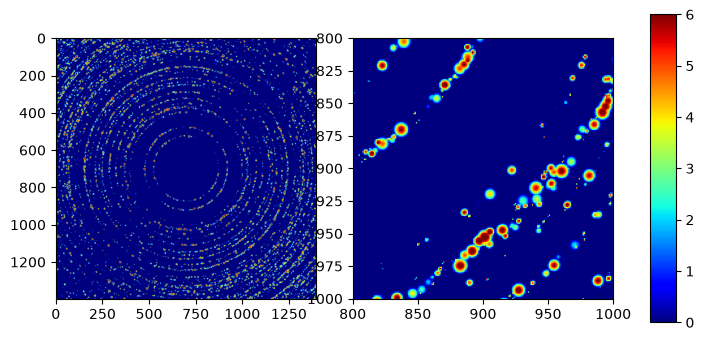

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(8, 4), width_ratios=(1, 1, 0.1))
img = axs[0].imshow(np.log10(f+1e0), cmap="jet", vmax = 6)


img = axs[1].imshow(np.log10(f+1e0), cmap="jet", vmax = 6)
axs[1].set_xlim(800, 1000)
axs[1].set_ylim(1000, 800)
fig.colorbar(img, cax = axs[2])

plt.show()


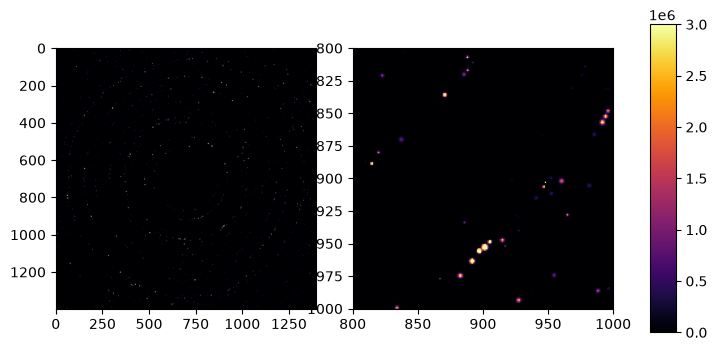

In [18]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(8, 4), width_ratios=(1, 1, 0.1))
img = axs[0].imshow(f, cmap="inferno", vmax = 3e6)


img = axs[1].imshow(f, cmap="inferno", vmax = 3e6)
axs[1].set_xlim(800, 1000)
axs[1].set_ylim(1000, 800)
fig.colorbar(img, cax = axs[2])

plt.show()


In [14]:
motion = RigidBodyMotion(
   rotation_axis=axis,
   rotation_angle=angle,
   translation=np.array([0, 0, 0]),
)

plt.show()
peaks_dict = polycrystal.diffract(beam, motion, detector=detector)
diffraction_pattern, peaks_dict = detector.render(
   peaks_dict, frames_to_render=0, method="micro"
)

pattern = (
   diffraction_pattern[0].cpu().numpy()
   if hasattr(diffraction_pattern, "cpu")
   else diffraction_pattern[0]
)


[Detector.render] frames_to_render < 1, setting to 1
[Micro] Batch 1/1                                       |████████████████████████████████████████| 100.0%


/tmp/ipykernel_106212/425597058.py:9: UserWarning: Skipping 3 peaks with invalid intensity factors: 3 with infinite Lorentz factor (eta ≈ 0°/180° or θ ≈ 0°). These represent geometrically impossible reflections.
  diffraction_pattern, peaks_dict = detector.render(


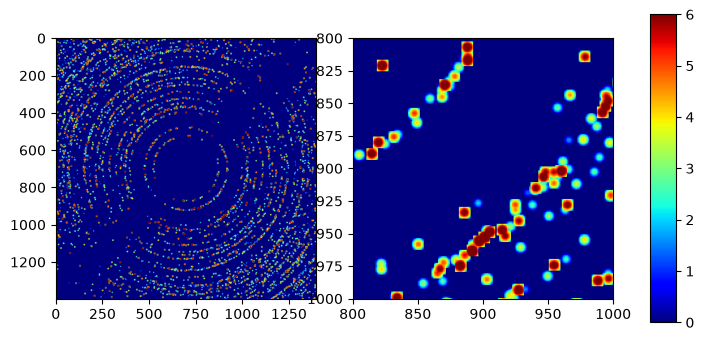

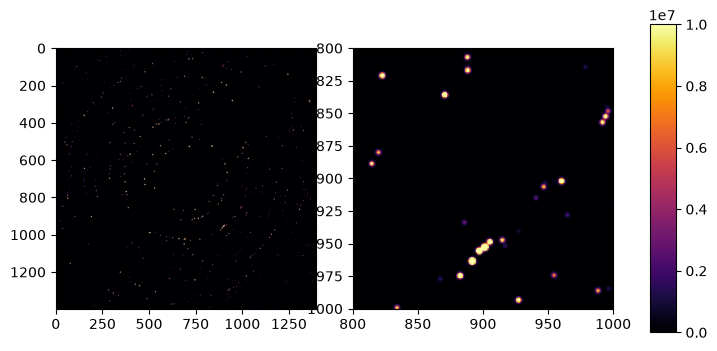

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4), width_ratios=(1, 1, 0.1))
img = axs[0].imshow(np.log10(pattern+1e0), cmap="jet", vmax = 6)


img = axs[1].imshow(np.log10(pattern+1e0), cmap="jet", vmax = 6)
axs[1].set_xlim(800, 1000)
axs[1].set_ylim(1000, 800)
fig.colorbar(img, cax = axs[2])

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(8, 4), width_ratios=(1, 1, 0.1))
img = axs[0].imshow(pattern, cmap="inferno", vmax = 1e7)


img = axs[1].imshow(pattern, cmap="inferno", vmax = 1e7)
axs[1].set_xlim(800, 1000)
axs[1].set_ylim(1000, 800)
fig.colorbar(img, cax = axs[2])

plt.show()